### **Exploratory Data Analysis (EDA)**

**Load Libraries**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

**Load News Data**

In [4]:
news_df = pd.read_csv('../data/raw/newsData/raw_analyst_ratings.csv')

**Clean & Format**

In [5]:
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
news_df['stock'] = news_df['stock'].str.upper().str.strip()

**Descriptive Statistics**

In [6]:
news_df['headline_len'] = news_df['headline'].apply(lambda x: len(str(x)))

**Topic Analysis - Top Phrases**

In [7]:
def get_top_bigrams(corpus, n=10):
    vec = CountVectorizer(stop_words='english', ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

# Filter out rows where headline is missing
clean_headlines = news_df['headline'].dropna()
top_phrases = get_top_bigrams(clean_headlines)
print(top_phrases)

[('52 week', np.int64(51006)), ('price target', np.int64(47274)), ('stocks moving', np.int64(40044)), ('mid day', np.int64(37324)), ('market update', np.int64(33101)), ('earnings scheduled', np.int64(32055)), ('initiates coverage', np.int64(28993)), ('pre market', np.int64(28393)), ('raises pt', np.int64(27213)), ('companies trading', np.int64(23170))]


**Visualization**

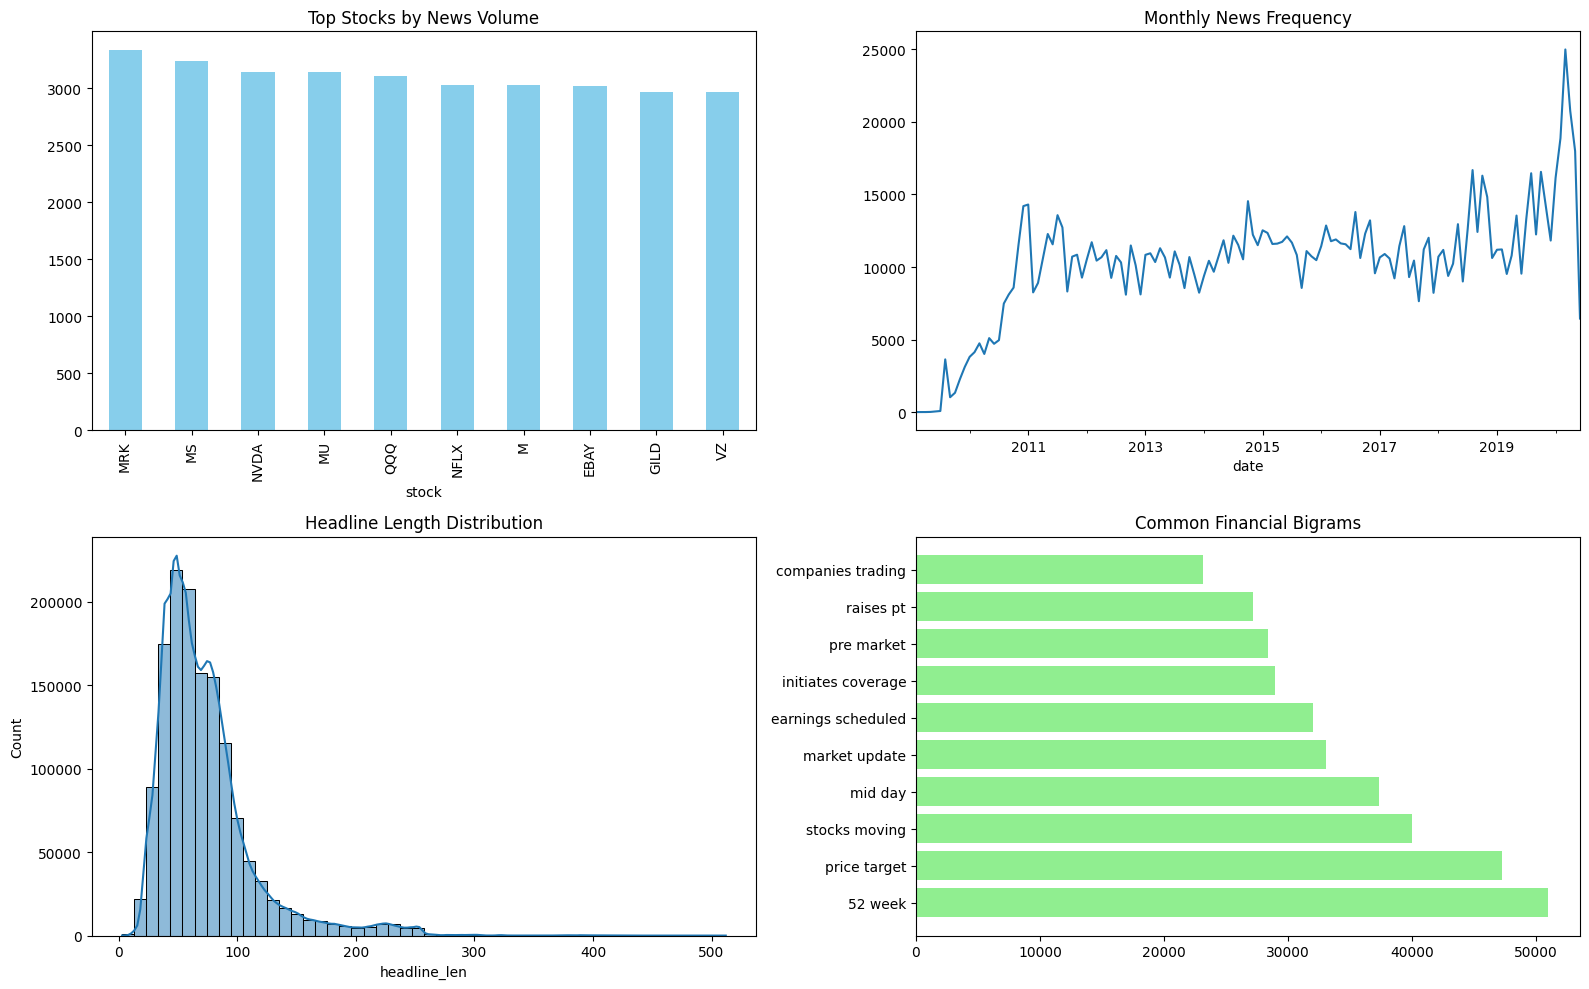

In [8]:
plt.figure(figsize=(16, 10))

# Plot A: Articles per Stock
plt.subplot(2, 2, 1)
news_df['stock'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top Stocks by News Volume')

# Plot B: Publication Trend
plt.subplot(2, 2, 2)
news_df.set_index('date').resample('ME').size().plot()
plt.title('Monthly News Frequency')

# Plot C: Headline Lengths
plt.subplot(2, 2, 3)
sns.histplot(news_df['headline_len'], bins=50, kde=True)
plt.title('Headline Length Distribution')

# Plot D: Top Phrases
plt.subplot(2, 2, 4)
words, counts = zip(*top_phrases)
plt.barh(words, counts, color='lightgreen')
plt.title('Common Financial Bigrams')

plt.tight_layout()
plt.show()